## Multi-signal example: Librosa's Trumpet

#### Load data. Add Sensor/Channel variance and noise

In [7]:
import librosa
import numpy as np

y, sr = librosa.load(librosa.ex('trumpet'), duration=3.5)

Y = np.zeros((5,3, len(y)))

# R = np.random.rand(Y.shape[0], Y.shape[1])
np.random.seed(212)
sensor_var  = np.abs(np.random.normal(0, scale = 10, size = Y.shape[0]))
channel_var = np.abs(np.random.normal(0, scale = 2, size = Y.shape[1]))
R = np.outer(sensor_var, channel_var)
R[0,0] = 1

sensors = ["A", "B", "C", "D", "E"]
# sensors = ["A"]
channels = ["HHE", "HHN", "HHZ"]

for b in range(Y.shape[0]):
    for c in range(Y.shape[1]):
        channel = (y * R[b,c]) + 1.25*np.random.rand(y.shape[0])
        Y[b,c,:] = channel


#### STFT feature extraction

In [8]:
from mesa.features import stft, stft_labels

# STFT params
window_length = int(0.05*sr)
hop = window_length//4
window = "blackman"
n_bins = window_length
center = True

D = stft(Y,window_length,hop, center=center)
Sxx = np.abs(D)**2
Sxx = librosa.amplitude_to_db(np.abs(D))


times, freqs = stft_labels(D, sr, hop, window_length)

#### Visualization

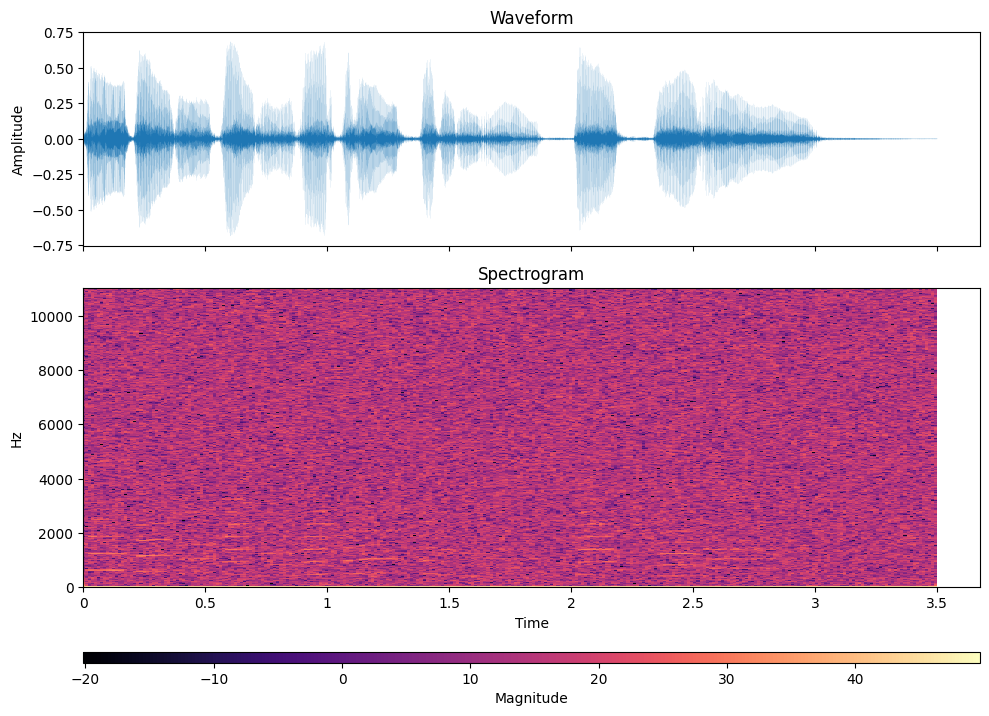

In [9]:
from mesa.visualization import spectrogram, dual_plot, multi_spectrogram, plot_signal

dual_plot(y, Sxx[0,0],sr,window_length,hop, center=center, cmap="magma");

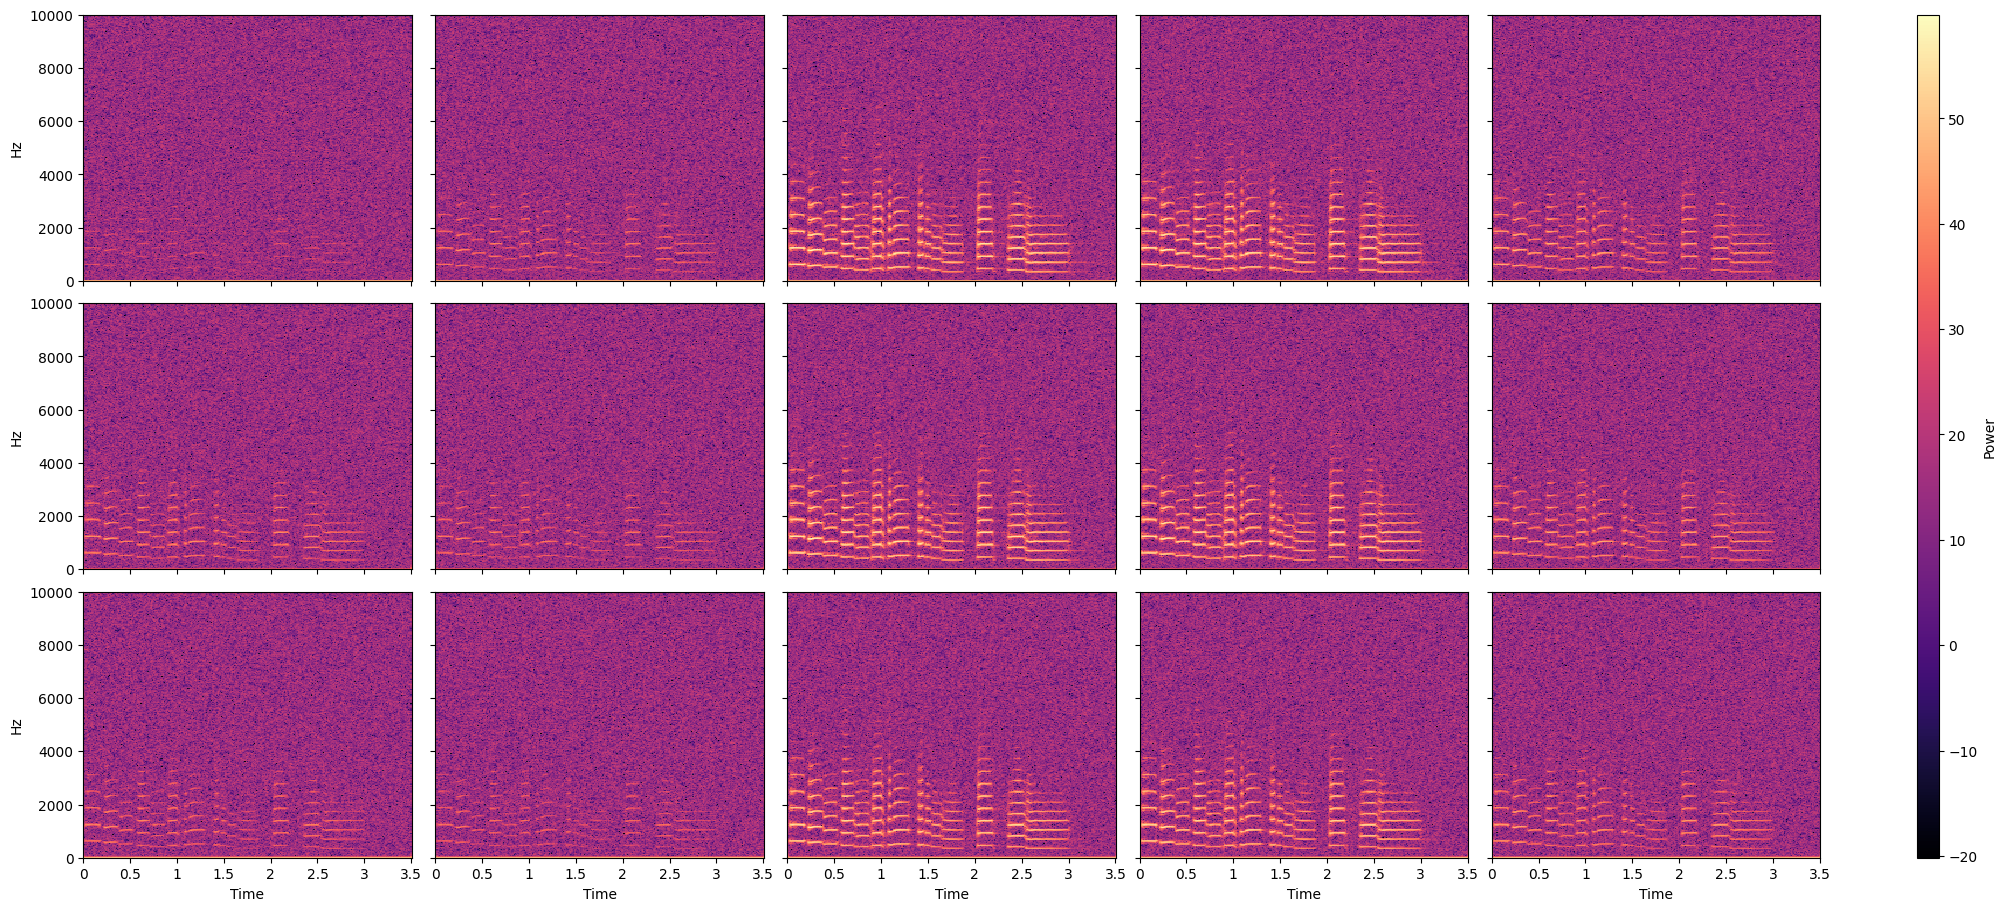

In [10]:
fig, axes = multi_spectrogram(Sxx, [1], [0],sr, window_length, hop=hop, cmap="magma")
# for ax in axes: ax.set_ylim(0,50)
for row in axes:
    row[0].set_ylim(0,10000)

#### Unfold Tensor

In [11]:
from mesa.fusion import unfold_2D

labels = [sensors, channels, freqs, times]
label_names = ["sensor", "channel", "freq", "time"]
X_unfold, labels_unfold, label_names = unfold_2D(Sxx,rows=[3], cols=[0,1,2], labels=labels, label_names=label_names)

#### Save .mat file

In [12]:
from scipy.io import savemat

savemat(
    "trumpet.mat", {"data": X_unfold,
                    "label_names": label_names,
                    "obs_l": np.array(labels_unfold[0], dtype=object),
                    "var_l": np.array(labels_unfold[1], dtype=object)}
)